# 01 — July 2019 pilot: domain and source-field quality-control reference

**Purpose.** Use the **July 2019 pilot data** to confirm that the spatial domain contains all
of Germany, Austria, and Switzerland and to inspect source-field quality. This notebook is
reproducibility and input-QC evidence; it is **not part of the 2018 scientific analysis** in
notebooks 02–06.

The preprocessing envelope is **5.5–17.25°E, 45.5–55.25°N**, chosen from Natural Earth 1:50m
boundaries so that it contains all three countries. This rectangle is only a pre-crop: all
calculations use a political-boundary mask for Germany, Austria, and Switzerland.

## 1. Setup and load the committed compact QC assets

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import pandas as pd
import xarray as xr
ROOT = Path.cwd()
ASSETS = ROOT / "app_assets" / "2018"
sys.path.insert(0, str(ROOT / "src"))
from cosmo_rea6_pipeline import LAT_BOUNDS, LON_BOUNDS, build_country_masks, load_dach_geometries

ds = xr.open_dataset(ASSETS / "cosmo_rea6_dach_2018_annual_means.nc")
raw = xr.open_dataset(ASSETS / "cosmo_rea6_dach_201907_source_qc.nc")
ds

<xarray.Dataset> Size: 911kB
Dimensions:            (y: 188, x: 151)
Coordinates:
  * y                  (y) int64 2kB 0 1 2 3 4 5 6 ... 182 183 184 185 186 187
  * x                  (x) int64 1kB 0 1 2 3 4 5 6 ... 145 146 147 148 149 150
    latitude           (y, x) float64 227kB ...
    longitude          (y, x) float64 227kB ...
    step               float64 8B ...
    heightAboveGround  float64 8B ...
    surface            float64 8B ...
Data variables:
    wind_cf            (y, x) float32 114kB ...
    solar_cf           (y, x) float32 114kB ...
    combined_cf        (y, x) float32 114kB ...
    ghi                (y, x) float32 114kB ...

## 2. Verify the country extents

These extents come from the same Natural Earth country polygons used to construct the
calculation mask. Grid cells are selected when their centres fall inside one of the
three polygons.

In [2]:
geometries = load_dach_geometries()
extent_table = pd.DataFrame(
    [
        {"country": country, "west": geom.bounds[0], "south": geom.bounds[1],
         "east": geom.bounds[2], "north": geom.bounds[3]}
        for country, geom in geometries.items()
    ]
).set_index("country").round(3)
extent_table

,west,south,east,north
country,,,,
Switzerland,5.970,45.830,10.455,47.776
Germany,5.858,47.279,15.017,55.059
Austria,9.524,46.400,17.147,49.001


## 3. Verify the applied DACH mask

In [3]:
country_masks = build_country_masks(ds)
mask = country_masks["mask_de"] | country_masks["mask_at"] | country_masks["mask_ch"]
valid = np.isfinite(ds["wind_cf"])
pd.Series({
    "grid dimensions (y, x)": str(dict(ds.sizes)),
    "pre-crop grid cells (y × x)": mask.size,
    "cells inside DACH borders": int(mask.sum()),
    "German model cells": int(country_masks["mask_de"].sum()),
    "Austrian model cells": int(country_masks["mask_at"].sum()),
    "Swiss model cells": int(country_masks["mask_ch"].sum()),
    "finite annual-wind cells inside DACH": int((valid & mask).sum()),
    "mask source": "Natural Earth 1:50m; grid-centre assignment",
}, name="domain check")

grid dimensions (y, x)                                         {'y': 188, 'x': 151}
pre-crop grid cells (y × x)                                                   28388
cells inside DACH borders                                                     12874
German model cells                                                             9530
Austrian model cells                                                           2243
Swiss model cells                                                              1101
finite annual-wind cells inside DACH                                          12874
mask source                             Natural Earth 1:50m; grid-centre assignment
Name: domain check, dtype: object

## 4. Reference map

These counts are **model/reanalysis grid cells**, not power plants or observations. Later,
SMARD validation uses one national daily time-series record per date and technology. SMARD is
not gridded, so there is no comparable count of "observed German grid cells."

A cell is assigned to a country when its **grid centre** falls inside the country polygon.
This is clear and reproducible, but a coastal or border cell can straddle land, sea, or two
countries. Centre-point masking does not calculate fractional land or country area.

Blue cells are the actual grid-cell centres used in the energy calculations. The red
rectangle is only the pre-crop envelope. Country outlines provide political context.

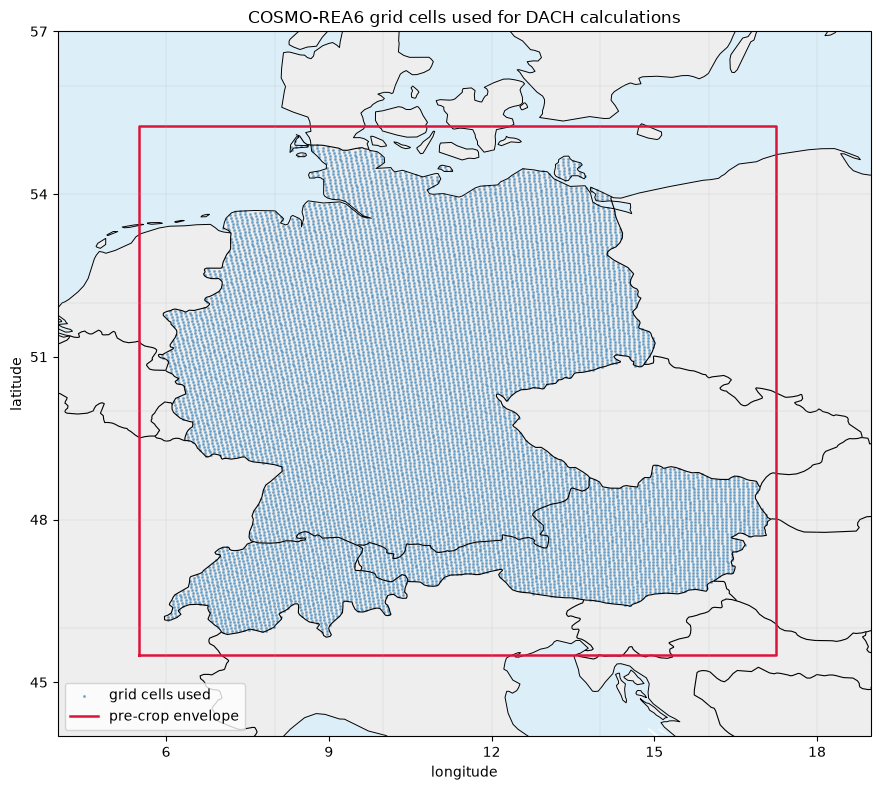

In [4]:
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([4, 19, 44, 57], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND.with_scale("50m"), facecolor="#eeeeee")
ax.add_feature(cfeature.OCEAN.with_scale("50m"), facecolor="#dceef8")
ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.7)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.8)

ax.scatter(
    ds.longitude.where(mask), ds.latitude.where(mask), s=1.5, color="#2878b5",
    alpha=0.45, transform=ccrs.PlateCarree(), label="grid cells used"
)
west, east = LON_BOUNDS
south, north = LAT_BOUNDS
ax.plot(
    [west, east, east, west, west], [south, south, north, north, south],
    color="crimson", linewidth=1.8, transform=ccrs.PlateCarree(), label="pre-crop envelope"
)
ax.gridlines(draw_labels=False, linewidth=0.3, alpha=0.5)
ax.set_xticks([6, 9, 12, 15, 18], crs=ccrs.PlateCarree())
ax.set_yticks([45, 48, 51, 54, 57], crs=ccrs.PlateCarree())
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title("COSMO-REA6 grid cells used for DACH calculations")
ax.legend(loc="lower left")
plt.tight_layout()

plt.show()

## 5. Load and inventory the downloaded climate variables

**Global horizontal irradiance (GHI)** is shortwave solar power arriving on a horizontal
surface: direct horizontal plus diffuse horizontal irradiance. Here the exact source geometry
is the COSMO-REA6 surface fields `ASWDIR_S + ASWDIFD_S`; both are downward horizontal fluxes,
so GHI is in W m⁻². For example, GHI = 500 W m⁻² means each horizontal square metre receives
500 joules per second at that time (or for these files, as a daily-mean rate).

The five source fields are shown before any energy conversion. This is an essential
climate-data quality-control step: it can reveal unit errors, missing areas, discontinuities,
implausible gradients, or a misaligned country mask.

In [5]:
raw_variables = ["t2m", "aswdir_s", "aswdifd_s", "u10", "v10"]
labels = {
    "t2m": "2 m air temperature",
    "aswdir_s": "direct downward shortwave radiation",
    "aswdifd_s": "diffuse downward shortwave radiation",
    "u10": "10 m zonal wind component",
    "v10": "10 m meridional wind component",
}
inventory = pd.DataFrame([
    {
        "variable": name,
        "description": labels[name],
        "units": raw[f"{name}_mean"].attrs.get("units", "not reported"),
        "minimum": raw.attrs[f"{name}_minimum"],
        "maximum": raw.attrs[f"{name}_maximum"],
    }
    for name in raw_variables
]).set_index("variable")
inventory

,description,units,minimum,maximum
variable,,,,
t2m,2 m air temperature,K,271.331299,306.755371
aswdir_s,direct downward shortwave radiation,W m-2,0.000000,282.585938
aswdifd_s,diffuse downward shortwave radiation,W m-2,6.382772,248.525894
u10,10 m zonal wind component,m s**-1,-9.925797,13.006722
v10,10 m meridional wind component,m s**-1,-8.392870,5.743697


## 6. Mapping helper for source-field checks

Each panel uses its own color scale because the variables have different units and ranges.
Borders and coastlines are overlaid, and values outside the DACH political mask remain blank.

In [6]:
def plot_source_fields(suffix, heading):
    fig, axes = plt.subplots(
        3, 2, figsize=(13, 14),
        subplot_kw={"projection": ccrs.PlateCarree()},
    )
    for ax, name in zip(axes.flat, raw_variables):
        field = raw[f"{name}_{suffix}"].where(mask)
        image = ax.pcolormesh(
            raw.longitude, raw.latitude, field,
            shading="auto", cmap="viridis", transform=ccrs.PlateCarree(),
        )
        ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.8)
        ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.6)
        ax.set_extent([5.5, 17.25, 45.5, 55.25], crs=ccrs.PlateCarree())
        ax.set_xticks([6, 9, 12, 15], crs=ccrs.PlateCarree())
        ax.set_yticks([46, 49, 52, 55], crs=ccrs.PlateCarree())
        ax.set_xlabel("longitude")
        ax.set_ylabel("latitude")
        unit = field.attrs.get("units", "")
        ax.set_title(f"{labels[name]} ({name})")
        fig.colorbar(image, ax=ax, shrink=0.78, label=unit)
    axes.flat[-1].set_visible(False)
    fig.suptitle(heading, fontsize=15, y=0.995)
    fig.tight_layout()
    plt.show()

## 7. First available daily time step

This snapshot is the daily-mean field timestamped at the first time coordinate in July 2019.
It is useful for detecting localized artifacts and checking whether wind and radiation
patterns are meteorologically coherent. It is **not** an instantaneous weather map because
the downloaded COSMO-REA6 product contains daily means.

First daily-mean timestamp: 2019-07-01 01:00:00


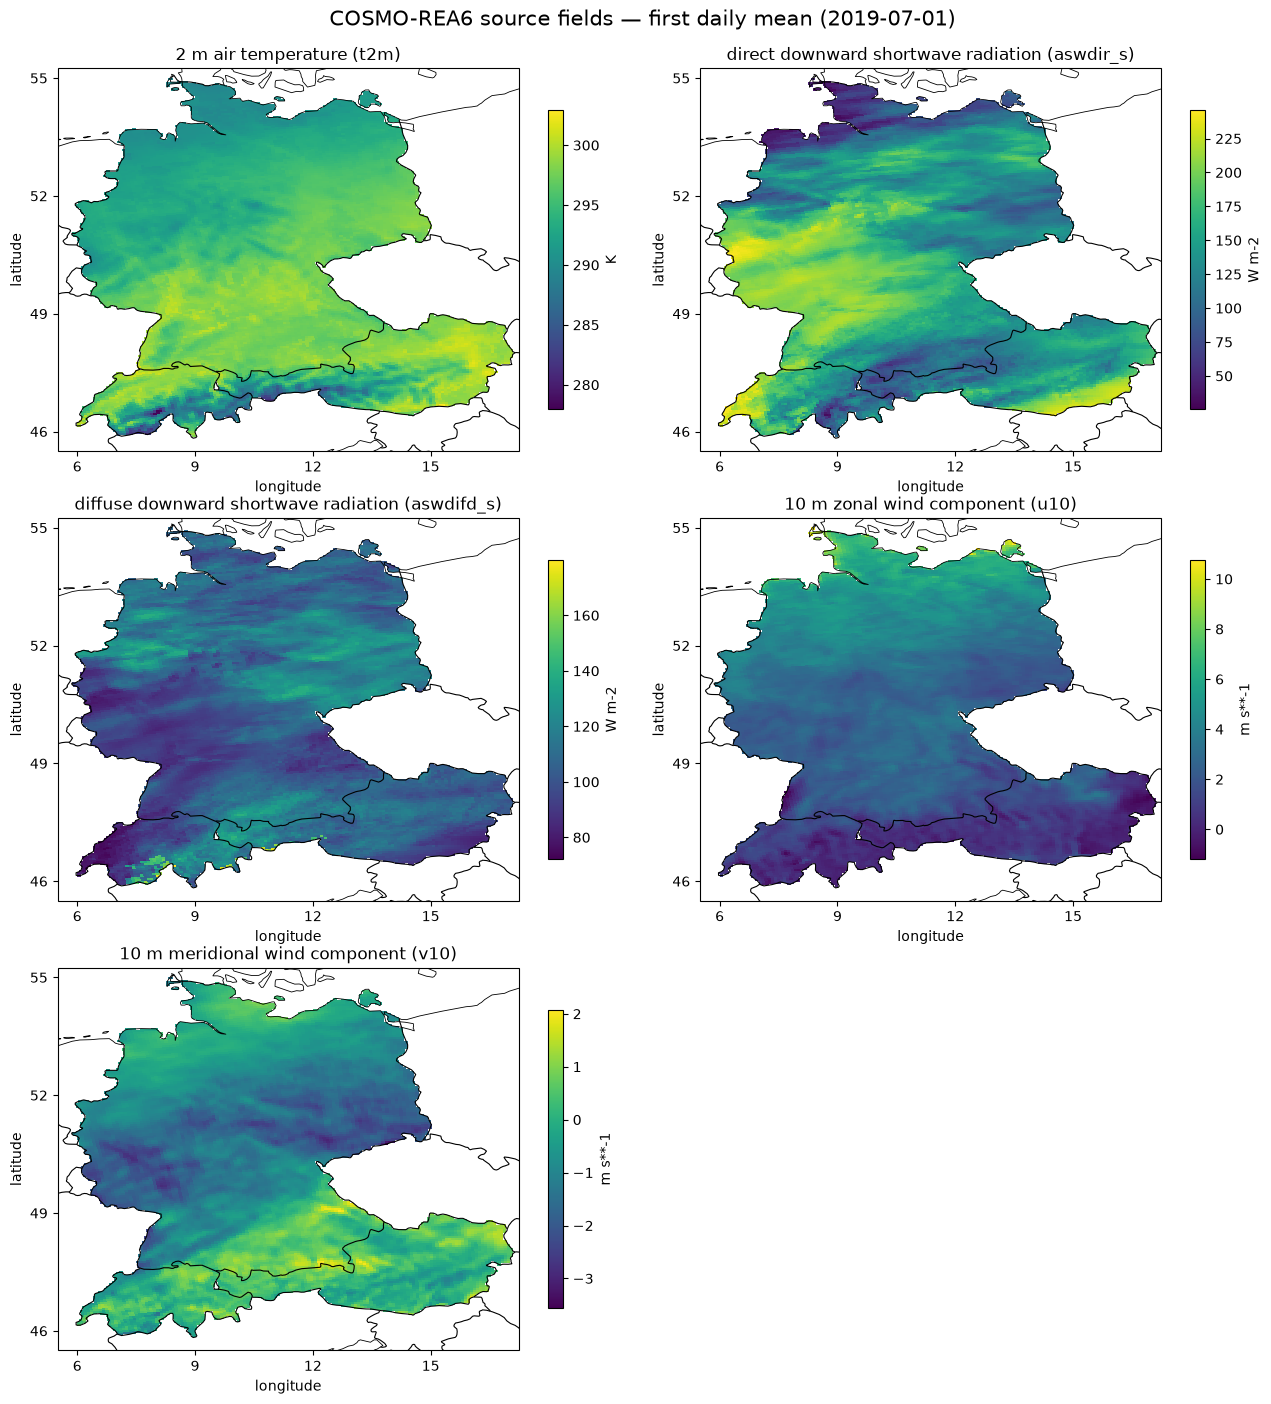

In [7]:
first_time = pd.Timestamp(raw.attrs["first_time"])
print(f"First daily-mean timestamp: {first_time}")
plot_source_fields(
    "first",
    f"COSMO-REA6 source fields — first daily mean ({first_time:%Y-%m-%d})",
)

## 8. July 2019 monthly means

Monthly means suppress day-to-day weather variability and reveal persistent spatial
gradients. They are meaningful for all five inputs, although mean `u10` and `v10` describe
the prevailing vector components and should not be interpreted as mean wind speed.

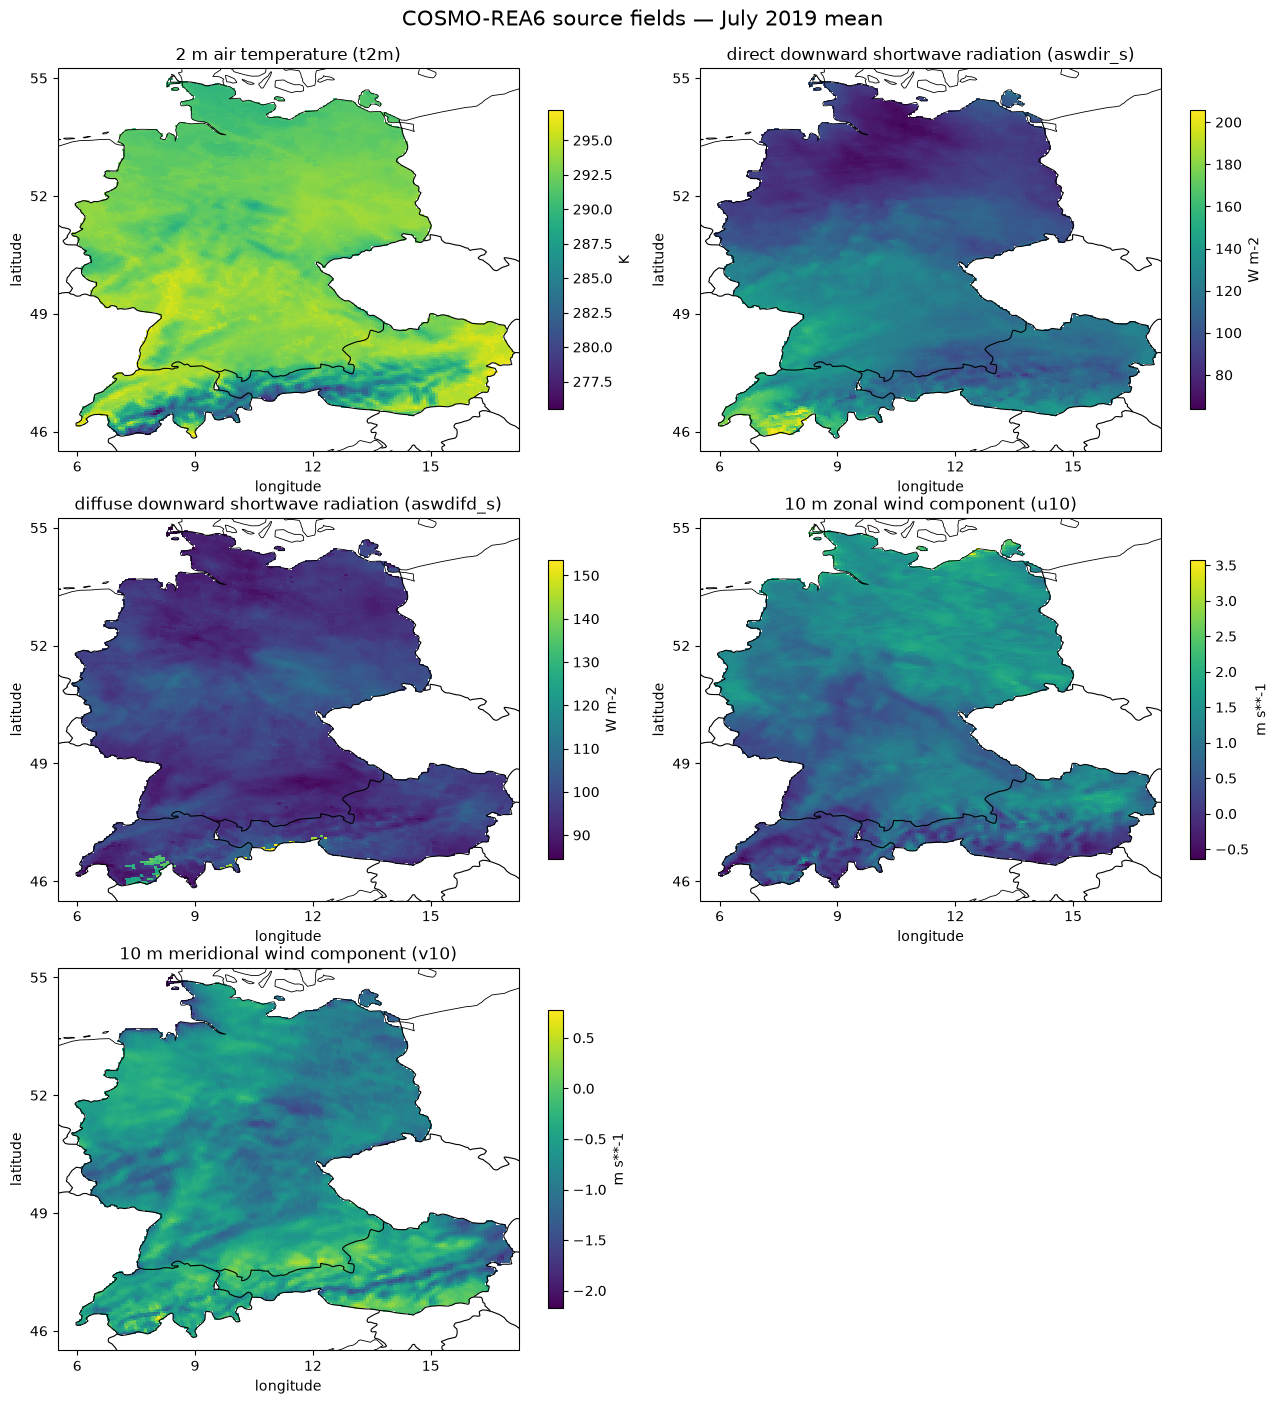

In [8]:
plot_source_fields(
    "mean",
    "COSMO-REA6 source fields — July 2019 mean",
)

## Interpretation

- The envelope contains all of Germany, Austria, and Switzerland.
- The rectangular envelope itself is **not** the analysis region.
- The Natural Earth grid-centre country masks define the calculation cells; the rectangle is only a pre-crop.
- The source maps retain native units: temperature in K, radiation in W m⁻², and wind
  components in m s⁻¹.
- `u10` and `v10` are signed vector components; negative values are physically meaningful.
- Small boundary discrepancies remain possible because a grid cell is assigned by its
  centre and Natural Earth is a generalized 1:50m administrative dataset.